# Lid-driven cavity flow with Staggered Grid

## Import Library

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, eye, kron
from scipy.sparse.linalg import factorized

## Domain Setup

In [34]:
L = 1.0
N = 64    # number of cells (N×N pressure grid)
dx = L / N
dy = L / N

Re    = 100.0
U_lid = 1.0
Nu    = U_lid * L / Re

# ── Staggered MAC grid ─────────────────────────────────────────────────────
# p : (N,   N  ) — cell centres
# u : (N,   N+1) — vertical faces   u[i,j] at x=j·dx,     y=(i+0.5)·dy
# v : (N+1, N  ) — horizontal faces v[i,j] at x=(j+0.5)·dx, y=i·dy
p = np.zeros((N,   N  ))
u = np.zeros((N,   N+1))
v = np.zeros((N+1, N  ))

# Cell-centre grid for visualisation
x_c = (np.arange(N) + 0.5) * dx
y_c = (np.arange(N) + 0.5) * dy
X_c, Y_c = np.meshgrid(x_c, y_c)

safety_factor = 0.4
dt = safety_factor / (U_lid/dx + U_lid/dy + 4*Nu/dx**2)
CFL = U_lid * dt / dx
r   = Nu   * dt / dx**2

print(f"Grid : {N}×{N} cells | dx = {dx:.4f}")
print(f"dt   = {dt:.6f} | CFL = {CFL:.4f} | r = {r:.4f}")
print(f"Combined 2·CFL + 4r = {2*CFL + 4*r:.4f}  (≤ 1)")

nt = 30000
print(f"T_final = {nt*dt:.3f}")

Grid : 64×64 cells | dx = 0.0156
dt   = 0.001371 | CFL = 0.0877 | r = 0.0561
Combined 2·CFL + 4r = 0.4000  (≤ 1)
T_final = 41.118


In [35]:
# ── Build sparse Poisson matrix once (Neumann BCs, p[0,0]=0 reference) ────
def build_poisson_matrix(N, dx, dy):
    d = np.full(N, -2.0); d[0] = d[-1] = -1.0   # Neumann: half-stencil at walls
    e = np.ones(N - 1)
    Lx = diags([e, d, e], [-1, 0, 1], format='csr') / dx**2
    Ly = diags([e, d, e], [-1, 0, 1], format='csr') / dy**2
    I  = eye(N, format='csr')
    L  = kron(I, Lx, format='csr') + kron(Ly, I, format='csr')
    L  = L.tolil(); L[0, :] = 0; L[0, 0] = 1   # pin p[0,0] = 0
    return L.tocsr()

A_poisson   = build_poisson_matrix(N, dx, dy)
solve_poisson = factorized(A_poisson)   # pre-factor LU once; each call is ~O(N²)
print(f"Poisson matrix {A_poisson.shape} built and LU-factorized.")

Poisson matrix (4096, 4096) built and LU-factorized.


## Algorithm Per Time Step

## Apply boundary conditions to u, v

In [36]:
def apply_boundary_conditions(u, v, U_lid=1.0):
    # u and v sit ON the faces, so normal-velocity BCs are enforced directly.
    # Tangential no-slip is handled via image (ghost) cells inside momentum_predictor.
    u[:, 0]  = 0.0   # left  wall — no penetration
    u[:, -1] = 0.0   # right wall — no penetration
    v[0,  :] = 0.0   # bottom wall — no penetration
    v[-1, :] = 0.0   # top wall   — lid moves in x only (v=0 here)
    return u, v

## Momentum Predictor - Compute u*, v* (momentum without pressure)

In [37]:
def momentum_predictor(u, v, p, dx, dy, dt, Nu, U_lid, N):
    un = u.copy()
    vn = v.copy()
    u_star = un.copy()
    v_star = vn.copy()

    # ── Ghost-cell extensions for tangential no-slip BCs ─────────────────
    # u: (N, N+1) → (N+2, N+1)  add image rows top/bottom
    u_ext = np.empty((N+2, N+1))
    u_ext[1:-1, :] = un
    u_ext[0,  :] = -un[0, :]              # bottom image: avg u at y=0   → 0
    u_ext[-1, :] = 2*U_lid - un[-1, :]   # top    image: avg u at y=L   → U_lid

    # v: (N+1, N) → (N+1, N+2)  add image cols left/right
    v_ext = np.empty((N+1, N+2))
    v_ext[:, 1:-1] = vn
    v_ext[:,  0] = -vn[:,  0]   # left  image: avg v at x=0 → 0
    v_ext[:, -1] = -vn[:, -1]  # right image: avg v at x=L → 0

    # ── u-momentum  (all N rows, interior cols j=1..N-1) ─────────────────
    # Stencil neighbours
    u_c = u_ext[1:-1, 1:-1]   # (N, N-1)  current face
    u_n = u_ext[2:,   1:-1]   # (N, N-1)  north
    u_s = u_ext[:-2,  1:-1]   # (N, N-1)  south
    u_e = un[:, 2:]            # (N, N-1)  east
    u_w = un[:, :-2]           # (N, N-1)  west

    # v interpolated to u-face positions (average of 4 surrounding v-faces)
    # v[i,j] at y=i·dy, x=(j+0.5)·dx → u-face at y=(i+0.5)·dy, x=j·dx
    v_at_u = (vn[:-1, :-1] + vn[:-1, 1:] + vn[1:, :-1] + vn[1:, 1:]) / 4  # (N, N-1)

    conv_ux = (np.maximum(u_c, 0)*(u_c - u_w) + np.minimum(u_c, 0)*(u_e - u_c)) / dx
    conv_uy = (np.maximum(v_at_u, 0)*(u_c - u_s) + np.minimum(v_at_u, 0)*(u_n - u_c)) / dy
    diff_u  = Nu * ((u_e - 2*u_c + u_w)/dx**2 + (u_n - 2*u_c + u_s)/dy**2)

    u_star[:, 1:-1] = u_c + dt * (diff_u - conv_ux - conv_uy)

    # ── v-momentum  (interior rows i=1..N-1, all N cols) ─────────────────
    v_c = vn[1:-1, :]     # (N-1, N)
    v_n = vn[2:,   :]     # (N-1, N)
    v_s = vn[:-2,  :]     # (N-1, N)
    v_e = v_ext[1:-1, 2:]  # (N-1, N)
    v_w = v_ext[1:-1, :-2] # (N-1, N)

    # u interpolated to v-face positions
    # u[i,j] at y=(i+0.5)·dy, x=j·dx → v-face at y=i·dy, x=(j+0.5)·dx
    u_at_v = (un[:-1, :-1] + un[:-1, 1:] + un[1:, :-1] + un[1:, 1:]) / 4  # (N-1, N)

    conv_vx = (np.maximum(u_at_v, 0)*(v_c - v_w) + np.minimum(u_at_v, 0)*(v_e - v_c)) / dx
    conv_vy = (np.maximum(v_c, 0)*(v_c - v_s) + np.minimum(v_c, 0)*(v_n - v_c)) / dy
    diff_v  = Nu * ((v_e - 2*v_c + v_w)/dx**2 + (v_n - 2*v_c + v_s)/dy**2)

    v_star[1:-1, :] = v_c + dt * (diff_v - conv_vx - conv_vy)

    return u_star, v_star

## Compute divergence b = ∇·u*

In [38]:
def compute_divergence(u_star, v_star, dx, dy):
    # Staggered Δx stencil: right face − left face of each pressure cell
    # u_star: (N, N+1)  →  u_star[:, 1:] − u_star[:, :-1]  shape (N, N)
    # v_star: (N+1, N)  →  v_star[1:, :] − v_star[:-1, :]  shape (N, N)
    div = (u_star[:, 1:] - u_star[:, :-1]) / dx + \
          (v_star[1:, :] - v_star[:-1, :]) / dy
    return div   # shape (N, N) — one value per pressure cell

## Connector - Pressure Poisson Solver

In [39]:
def pressure_poisson_connector(u_star, v_star, p, dx, dy, dt, rho=1.0):
    div = compute_divergence(u_star, v_star, dx, dy)   # (N, N)
    b   = (rho / dt) * div.flatten()
    b[0] = 0.0                    # consistent with p[0,0] = 0 reference
    return solve_poisson(b).reshape(N, N)

## Correct: u = u* - dt·∂p/∂x,  v = v* - dt·∂p/∂y

In [40]:
def velocity_corrector(u_star, v_star, p, dx, dy, dt, rho=1.0):
    u = u_star.copy()
    v = v_star.copy()

    # Interior u-faces (j=1..N-1): dp/dx = (p[:,j] − p[:,j-1]) / dx
    # p[:,1:] − p[:,:-1] has shape (N, N-1) → matches u[:,1:-1]  ✓
    u[:, 1:-1] -= (dt/rho) * (p[:, 1:] - p[:, :-1]) / dx

    # Interior v-faces (i=1..N-1): dp/dy = (p[i,:] − p[i-1,:]) / dy
    # p[1:,:] − p[:-1,:] has shape (N-1, N) → matches v[1:-1,:]  ✓
    v[1:-1, :] -= (dt/rho) * (p[1:, :] - p[:-1, :]) / dy

    return u, v

## Track ${max|u^{n+1} - u^n|}$ for steady state convergence

In [41]:
def check_convergence(u, v, u_old, v_old, tol=1e-6):
    return (np.max(np.abs(u - u_old)) < tol and
            np.max(np.abs(v - v_old)) < tol)

## Main Loop

In [42]:
residual_history = []

u, v = apply_boundary_conditions(u, v, U_lid)

for n in range(nt):
    u_old = u.copy()
    v_old = v.copy()
    p_old = p.copy()

    u_star, v_star = momentum_predictor(u_old, v_old, p_old, dx, dy, dt, Nu, U_lid, N)
    p = pressure_poisson_connector(u_star, v_star, p_old, dx, dy, dt)
    u, v = velocity_corrector(u_star, v_star, p, dx, dy, dt)
    u, v = apply_boundary_conditions(u, v, U_lid)

    residual = np.max(np.abs(u - u_old))
    residual_history.append(residual)

    if n % 500 == 0:
        print(f"Step {n:5d} | residual = {residual:.2e}")

    if check_convergence(u, v, u_old, v_old):
        print(f"Converged at step {n}.")
        break
else:
    print("Did not converge within the maximum time steps.")

Step     0 | residual = 1.09e-01
Step   500 | residual = 4.06e-04
Step  1000 | residual = 1.56e-04
Step  1500 | residual = 7.99e-05
Step  2000 | residual = 4.69e-05
Step  2500 | residual = 2.93e-05
Step  3000 | residual = 1.88e-05
Step  3500 | residual = 1.23e-05
Step  4000 | residual = 8.14e-06
Step  4500 | residual = 5.40e-06
Step  5000 | residual = 3.59e-06
Step  5500 | residual = 2.39e-06
Step  6000 | residual = 1.59e-06
Step  6500 | residual = 1.06e-06
Converged at step 6608.


## Result Visualization

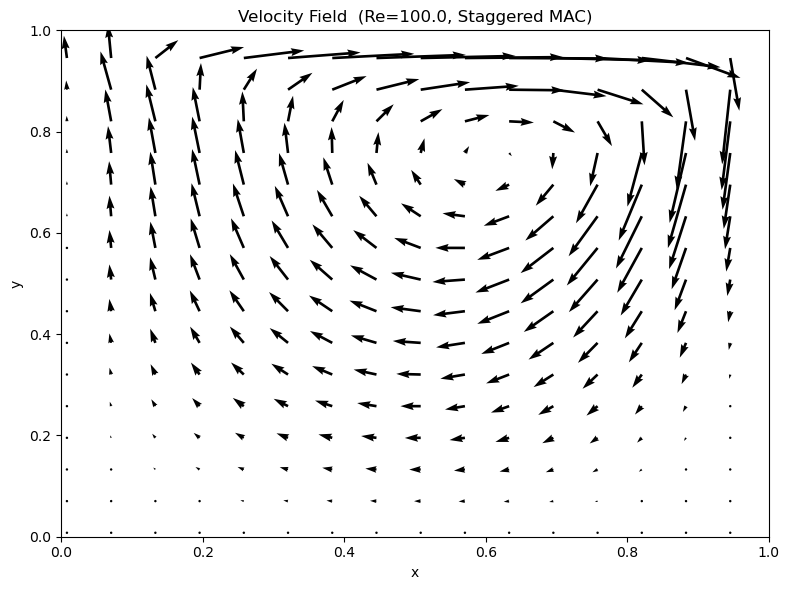

In [43]:
# Interpolate face velocities to cell centres for plotting
u_cell = (u[:, :-1] + u[:, 1:]) / 2   # (N, N)
v_cell = (v[:-1, :] + v[1:, :]) / 2   # (N, N)

step = 4
plt.figure(figsize=(8, 6))
plt.title(f"Velocity Field  (Re={Re}, Staggered MAC)")
plt.quiver(X_c[::step, ::step], Y_c[::step, ::step],
           u_cell[::step, ::step], v_cell[::step, ::step])
plt.xlabel('x'); plt.ylabel('y')
plt.xlim(0, L); plt.ylim(0, L)
plt.tight_layout(); plt.show()

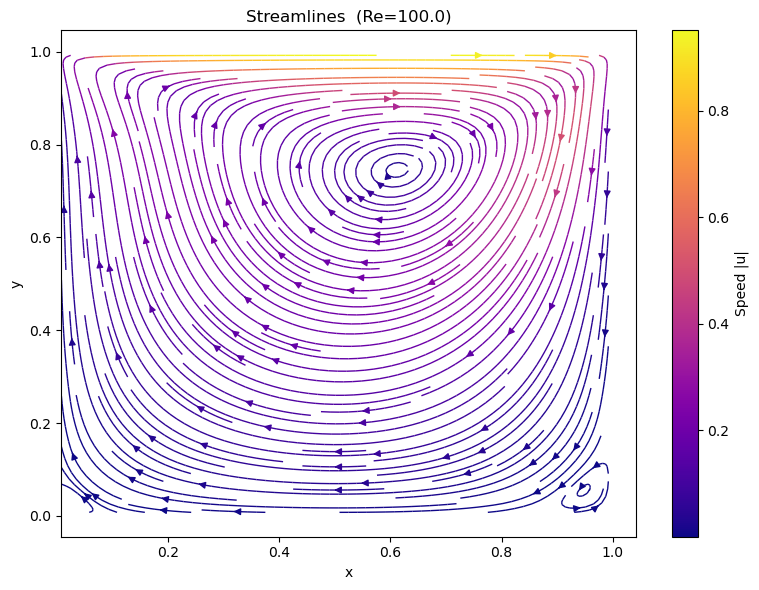

In [44]:
u_cell = (u[:, :-1] + u[:, 1:]) / 2
v_cell = (v[:-1, :] + v[1:, :]) / 2
speed  = np.sqrt(u_cell**2 + v_cell**2)
plt.figure(figsize=(8, 6))
plt.title(f"Streamlines  (Re={Re})")
plt.streamplot(x_c, y_c, u_cell, v_cell, density=2, color=speed, cmap='plasma', linewidth=1)
plt.colorbar(label='Speed |u|')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout(); plt.show()

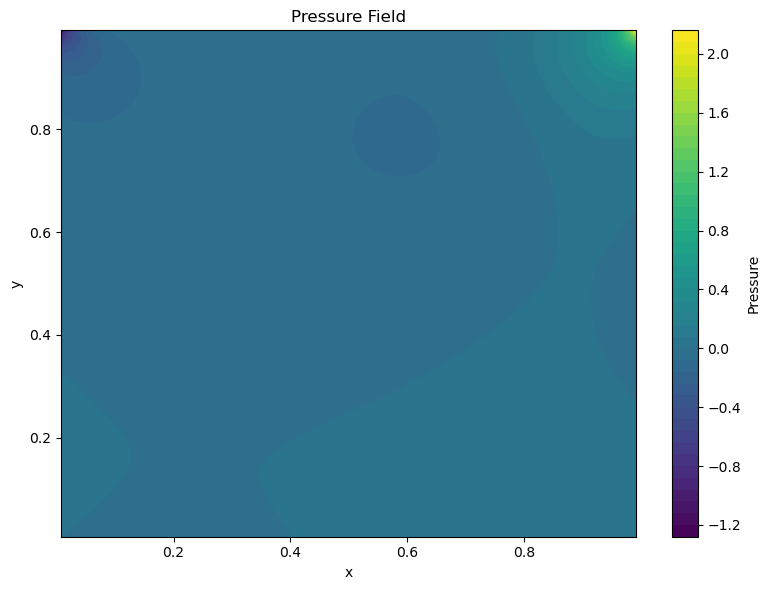

In [45]:
plt.figure(figsize=(8, 6))
plt.title("Pressure Field")
plt.contourf(X_c, Y_c, p, levels=50, cmap='viridis')
plt.colorbar(label='Pressure')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout(); plt.show()

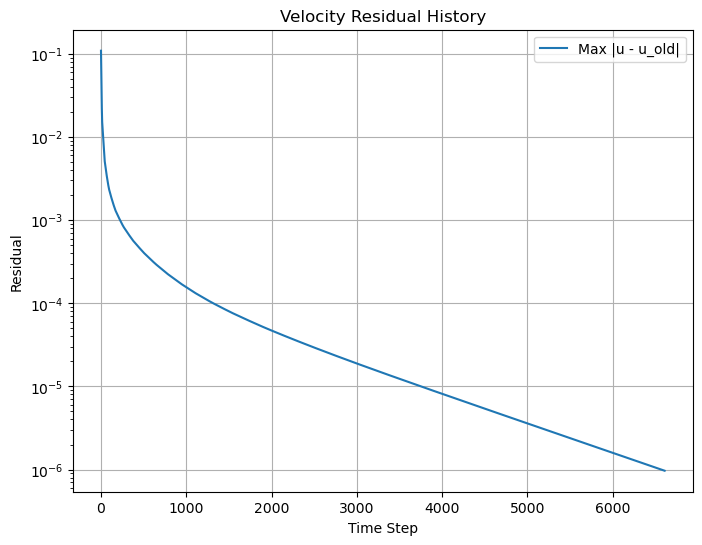

In [46]:
# Velocity Residual Plot
plt.figure(figsize=(8, 6))
plt.title("Velocity Residual History")
plt.semilogy(residual_history, label='Max |u - u_old|')
plt.xlabel('Time Step')
plt.ylabel('Residual')
plt.grid()
plt.legend()
plt.show()

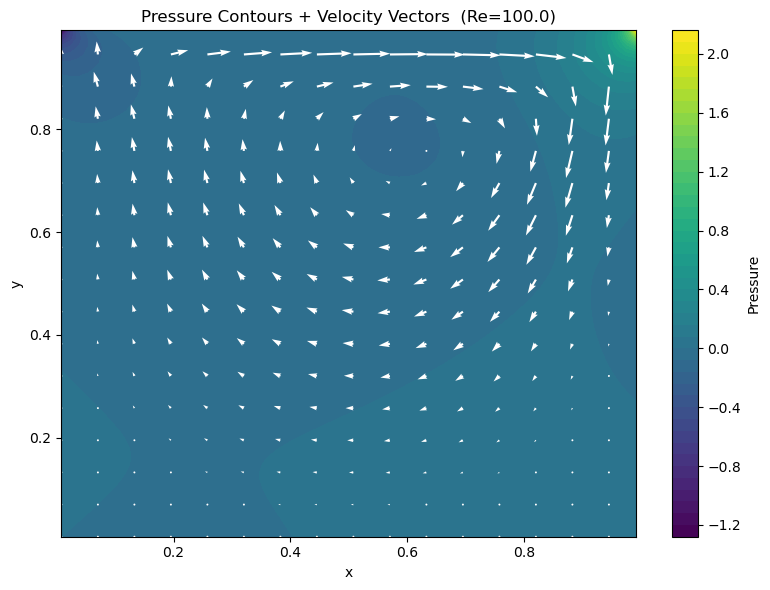

In [47]:
u_cell = (u[:, :-1] + u[:, 1:]) / 2
v_cell = (v[:-1, :] + v[1:, :]) / 2
step = 4
plt.figure(figsize=(8, 6))
plt.title(f"Pressure Contours + Velocity Vectors  (Re={Re})")
plt.contourf(X_c, Y_c, p, levels=50, cmap='viridis')
plt.colorbar(label='Pressure')
plt.quiver(X_c[::step, ::step], Y_c[::step, ::step],
           u_cell[::step, ::step], v_cell[::step, ::step],
           color='white', scale=10)
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout(); plt.show()

## Validation: Ghia et al. (1982) Benchmark

Compare centerline velocity profiles against the landmark paper:
**Ghia, Ghia & Shin (1982)** — *High-Re solutions for incompressible flow using the Navier-Stokes equations and a multigrid method*

- **u along x = 0.5** (vertical centerline): captures primary vortex strength
- **v along y = 0.5** (horizontal centerline): captures left/right recirculation

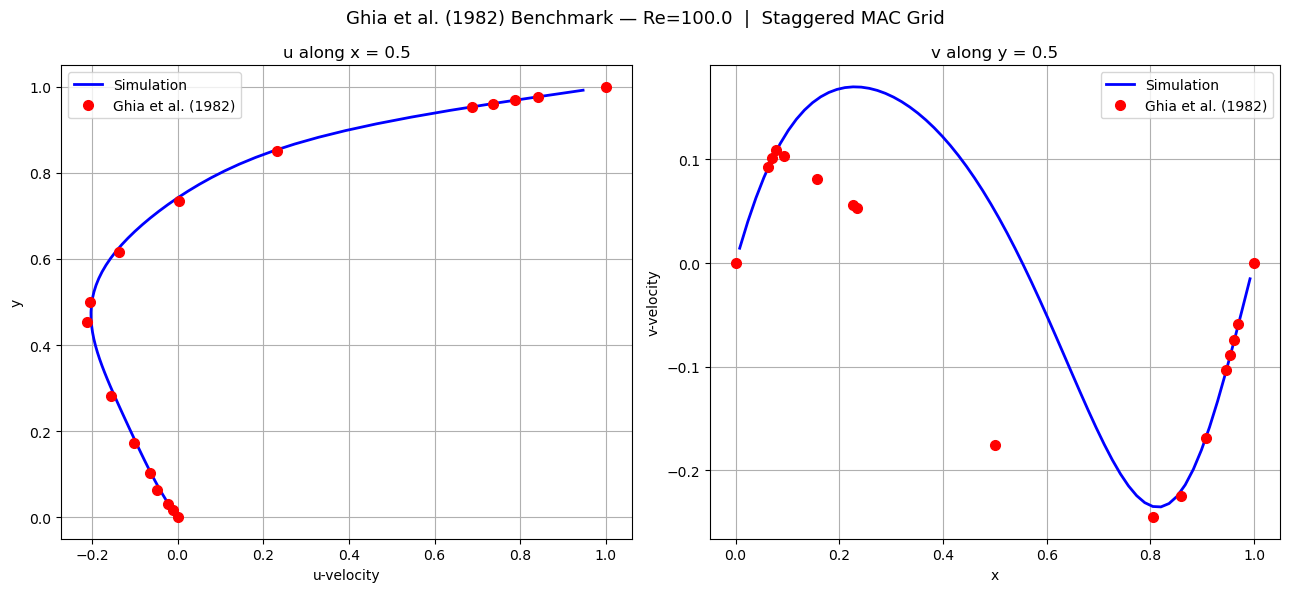

In [48]:
# Ghia et al. (1982) Re=100 benchmark data
ghia_y = [0.0000, 0.0156, 0.0313, 0.0625, 0.1016, 0.1719, 0.2813, 0.4531,
          0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]
ghia_u = [0.00000, -0.01160, -0.02347, -0.04775, -0.06434, -0.10150, -0.15662, -0.21090,
          -0.20581, -0.13641,  0.00332,  0.23151,  0.68717,  0.73722,  0.78871,  0.84123, 1.00000]

ghia_x = [0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344,
          0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]
ghia_v = [0.00000,  0.09233,  0.10091,  0.10890,  0.10313,  0.08066,  0.05602,  0.05334,
         -0.17527, -0.24533, -0.22445, -0.16914, -0.10313, -0.08864, -0.07391, -0.05906, 0.00000]

# Staggered grid: face positions (not cell centres)
y_u = (np.arange(N) + 0.5) * dy   # y-position of u-faces
x_v = (np.arange(N) + 0.5) * dx   # x-position of v-faces

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Ghia et al. (1982) Benchmark — Re={Re}  |  Staggered MAC Grid", fontsize=13)

# u along x=0.5: face column j = N//2 is at x = N//2·dx = 0.5 (for even N)
ax1.plot(u[:, N//2], y_u, "-b", linewidth=2, label="Simulation")
ax1.plot(ghia_u, ghia_y, "ro", markersize=7, label="Ghia et al. (1982)")
ax1.set_xlabel("u-velocity"); ax1.set_ylabel("y")
ax1.set_title("u along x = 0.5")
ax1.legend(); ax1.grid(True)

# v along y=0.5: face row i = N//2 is at y = N//2·dy = 0.5 (for even N)
ax2.plot(x_v, v[N//2, :], "-b", linewidth=2, label="Simulation")
ax2.plot(ghia_x, ghia_v, "ro", markersize=7, label="Ghia et al. (1982)")
ax2.set_xlabel("x"); ax2.set_ylabel("v-velocity")
ax2.set_title("v along y = 0.5")
ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()